# Example: Geo-intervention Modelling Framework

Demonstrates a simple example of the geo-intervention modelling framework.

## Libraries

In [80]:
import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString, Polygon

## Spatial Data Component

In [81]:
# Create locations as geometry
point = Point(43, -79)
line = LineString([(45, -79), (44, -78)])
polygon = Polygon([(46, -77), (47, -80), (48, -75)])

# Create initial spatial data
data = gpd.GeoDataFrame(
    {
        'i': [1, 2, 3],
        'Xi1': [1.25, 2.55, 5.75],
        'Xi2': [2, 4, 6],
        'Xi3': [0, 9.24, 33.14],
        'Li': [point, line, polygon]
    },
    geometry = 'Li'
)

# Spatial data engineering

# Calc new non spatial var
data['Xi1 + Xi2'] = data.Xi1 + data.Xi2

# Calc spatial var for nearest location i
data['Nearesti'] = data.Li.apply(
    lambda Li: data.distance(Li)
).apply(
    lambda Li: data.loc[Li[Li > 0].idxmin(), 'i']
)

# Calc spatial var for length of location geom
data['Length(Li)'] = data.Li.length

# Calc spatial var for type of location geom
data['Type(Li)'] = data.Li.type.replace('LineString', 'Line')

# Move location to the end
data = data[[c for c in data.columns if c != 'Li'] + ['Li']]

# Display spatial data results as table
data

,i,Xi1,Xi2,Xi3,Xi1 + Xi2,Nearesti,Length(Li),Type(Li),Li
0,1,1.25,2,0.00,3.25,2,0.000000,Point,POINT (43.00000 -79.00000)
1,2,2.55,4,9.24,6.55,1,1.414214,Line,"LINESTRING (45.00000 -79.00000, 44.00000 -78.0..."
2,3,5.75,6,33.14,11.75,2,11.089724,Polygon,"POLYGON ((46.00000 -77.00000, 47.00000 -80.000..."


/var/folders/lg/1tfppccd38s1sn9w5z9g_mcm0000gn/T/ipykernel_43731/2102279163.py:9: MatplotlibDeprecationWarning: The 's' parameter of annotate() has been renamed 'text' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  plt.annotate(


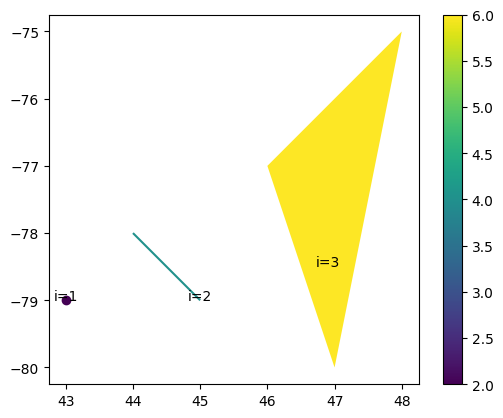

In [82]:
# Display spatial data results as map
data.plot(
    column = 'Xi2',
    legend = True
)

# Add labels for index i
for i, row in data.iterrows():
    plt.annotate(
        s = 'i=' + str(row['i']),
        xy = row['Li'].representative_point().coords[0],
        horizontalalignment = 'center'
    )

## Outcome Modelling Component

In [84]:
# Prepare outcome modelling data
model_data = pd.DataFrame(data.drop(columns = 'Li'))

# Select outcome var
model_data['Yi'] = model_data.pop('Xi3')
model_data

,i,Xi1,Xi2,Xi1 + Xi2,Nearesti,Length(Li),Type(Li),Yi
0,1,1.25,2,3.25,2,0.000000,Point,0.00
1,2,2.55,4,6.55,1,1.414214,Line,9.24
2,3,5.75,6,11.75,2,11.089724,Polygon,33.14


## Geo-intervention Generation Component